In [1]:
import sys

assert sys.version_info >= (3, 7)

from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

선형 회귀

In [2]:
import numpy as np

# 코드의 실행 결과 재현을 위해 난수 시드 고정
np.random.seed(42)

m = 100  # 샘플의 개수
# 균등 분포, [0.0, 1.0) 실수 반환
X = 2 * np.random.rand(m, 1) # 열 벡터
# 표준 정규 분포, -무한대에서 무한대의 모든 실수를 반환하나, 정규 분표 규칙 (68-95-99.7)을 따른다. 노이즈 추가
y = 3 * X + 4 + np.random.randn(m, 1) # 열 벡터

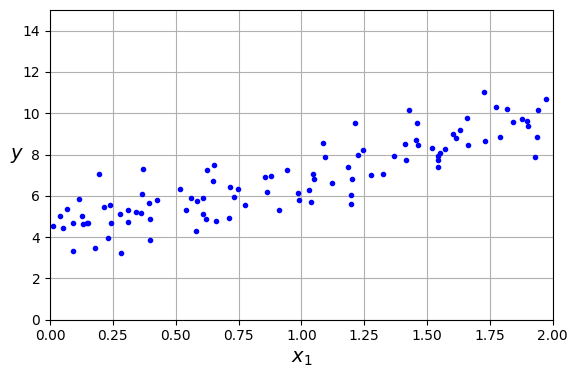

In [3]:
# x축 = feature, y축 = label

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

In [4]:
# 닫힌 형태의 방정식에서, 비용 함수를 최소화하는 파라미터를 즉시 찾을 수 있는 정규 방정식 사용

# 데이터 행렬의 맨 앞에 1로만 채워진 열을 추가
# -> 선형 회귀 모델의 가설 y = ax + b에서, 편향 b에 대한 연산 용이하게 처리
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # 각 샘플에 x0 = 1을 추가
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y # 정규 방정식을 통해 최적의 파라미터 계산

In [5]:
theta_best

array([[4.21509616],
       [2.77011339]])

**y = 3x + 4 + 가우스 노이즈** 에 대한 정규 방정식의 해

array([[4.21509616],
       [2.77011339]])

실제: Θ1 = 3, Θ2 = 4

예측: Θ1 = 4.215, Θ2= 2.770

In [6]:
X_new = np.array([[0], [2]]) # 2, 1

X_new_b = add_dummy_feature(X_new)

y_predict = X_new_b @ theta_best # x = 0, x = 2에서의 예측값 계산

y_predict

array([[4.21509616],
       [9.75532293]])

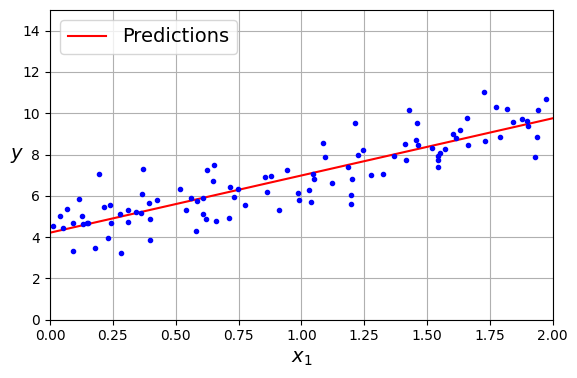

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # 추가 코드
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

In [8]:
# 사이킷런의 선형 회귀 모델 사용
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_reg.intercept_, lin_reg.coef_ # 가중치, 편향
# (array([4.21509616]), array([[2.77011339]]))

lin_reg.predict(X_new)
# array([[4.21509616],
#        [9.75532293]])

array([[4.21509616],
       [9.75532293]])

In [9]:
# 이전 정규방정식 풀이에서, 행렬식이 0이 아닌 정사각행렬이 아니라면 역행렬을 구할 수 없기 때문에,
# 특이값 분해를 통해 유사역행렬을 구하여 일반적인 상황에서도 정규방정식으로 풀 수 있다.

theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

정규 방정식은 (n + 1) * (n + 1) 크기의 X.T @ X 의 역행렬을 계산(n = 특성의 개수) -> 시간 복잡도는 O(n2.4) ~ O(n3), 계산 시간이 상당히 걸린다.

LinearRegression 클래스의 특잇값 분해, SVD 방식은 약 O(n2)이다.

경사 하강법

In [10]:
# 각 모델 파라미터에 대해 비용 함수의 기울기를 계산, 즉 각 파라미터에 대해 편도함수를 구한다.

eta = 0.5  # 학습률
n_epochs = 1000  # 에포크
m = len(X_b)  # 샘플 개수

np.random.seed(42)
theta = np.random.randn(2, 1)  # 임의의 파라미터

for epoch in range(n_epochs):
  gradients = 2/m * X_b.T @ (X_b @ theta - y)
  theta = theta - eta * gradients

# 졍규 방정식으로 찾은 결과와 같다.
theta

array([[-7.05138935e+27],
       [-7.98621001e+27]])

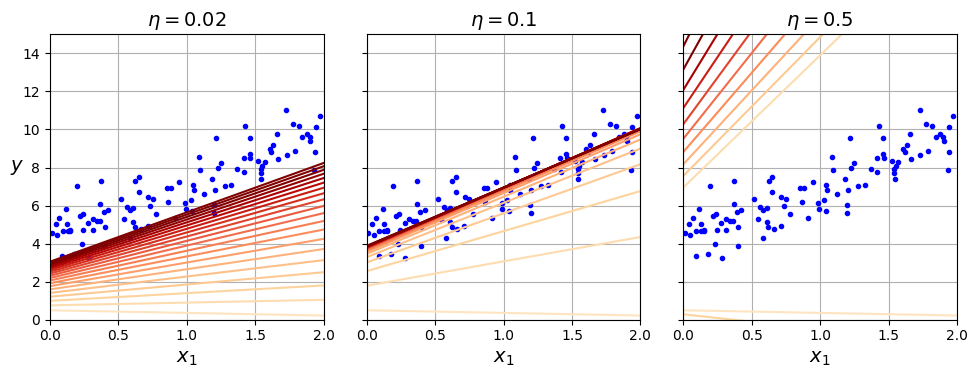

In [11]:
import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

# 하이퍼 파라미터인 학습률을 다르게 하여 학습할 수 있는데, 학습률을 0.02로 매우 작게 설정한 경우
# 주어진 에포크 내 최적점에 도달하지 못함을 보이며 학습률을 0.5로 매우 크게 설정한 경우
# 스텝마다 최적점에서 멀어쳐 결국 발산하는 모습을 보인다. 따라서 적절한 학습률을 찾기 위해 그리드 서치라는 기법을 사용한다.

# 반복 횟수인 에포크 또한 하이퍼 파라미터로 너무 작다면 최적점에 도달하기 전 학습이 종료되며
# 너무 크다면 파라미터가 최적점에 도달했음에도 학습이 계속해서 이루어지는 점이 있다.
# 이는 반복 횟수를 매우 크게 지정한 후 기울기 벡터의 노름이 작아지면, 즉 최적점에 허용 오차만큼 다가가면 학습을 중지할 수 있다.

In [12]:
# 위와 같은 배치 경사 하강법은 매 스텝마다 전체 훈련 세트를 사용하여 기울기를 계산하므로, 훈련 세트가 매우 커지만 학습 비용이 커진다.
# 이 때, 확률적 경사 하강법을 통해 하나의 샘플을 랜덤으로 선택한 후, 그 샘플에 대한 기울기를 계산하여 학습을 진행할 수 있다.
# 이는 매 스텝에서 하나의 샘플만 메모리를 사용하므로 빠르다는 장점이 있지만, 학습 경로가 불안정하며 최적점에 근접하더라도 안착하지 못할 가능성이 있다.
# 또한 지역 최솟값 문제의 관점에서, 불규칙한 학습 경로로 인해 배치 경사 하강법에 비해 전역 최솟값을 찾을 가능성이 높다는 점이 있다.

# 이러한 특징은 빠른 학습과 지역 최솟값 문제를 벗어날 수도 있다는 점에서 유리하지만, 전역 최솟값에 수렴하지 않을 수 있다는 점에
# 고정된 학습률이 아닌 매 반복마다 학습률을 결정하는 학습률 스케쥴러를 통해 점진적으로 학습률을 감소시킬 수 있다.

n_epochs = 50
t0, t1 = 5, 50  # 학습 스케줄 하이퍼 파라미터

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

theta

array([[4.21076011],
       [2.74856079]])

In [13]:
# 사이킷런에서의 확률적 경사 하강법, SGD
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)

sgd_reg.fit(X, y.ravel())

sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

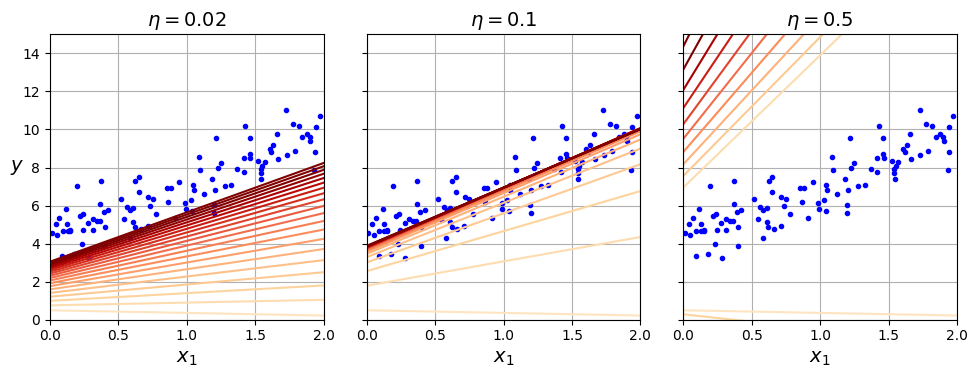

In [14]:
import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

In [15]:
# 배치와 확률적 경사 하강법에 이어 임의의 작은 샘플 세트에 대해 기울기를 계산하는 미니배치 경사 하강법이 존재한다.
# 미니배치 크기에 따라 배치 또는 확률적 경사 하강법의 특성과 유사해지며, 이 경우에도 적절한 학습 스케쥴을 적용할 수 있다.

In [16]:
# 만약 주어진 데이터가 선형이 아닌 비선형이라도, 선형 회귀 모델을 사용할 수 있다.

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
# 선형이 아닌 2차 방정식의 비선형 데이터를 생성
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

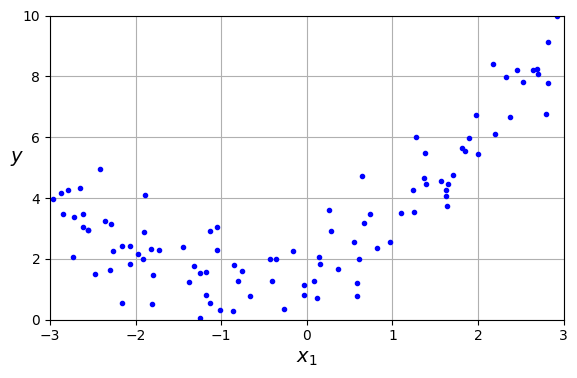

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_data_plot")
plt.show()

In [18]:
from sklearn.preprocessing import PolynomialFeatures

# 차수가 2인 제곱항을 추가, X_poly는 원래 특성 X와 이 특성의 제곱을 포함하게 된다.
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [19]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [20]:
# 확장된 훈련 데이터로 선형 회귀를 적용한다.
# 컴퓨터는 단지 선형적으로 새로운 특성을 예측하지만, 이 특성은 제곱이었으므로 결과적으로 비선형의 데이터를 예측하는 것과 동일해진다.
# 다항 회귀 임에도 선형 회귀로 풀 수 있는 이유는 y_hat = x^2*w1 + x*w2 + b에서 x 관점에서는 비선형이지만, 가중치 w 관점에서는 단지 각 특성과 가중치의 곱일 뿐이며
# 열벡터 x와 열벡터 w에 대해 y_hat = wT @ x + b와 동일, 즉 선형 결합과 완전히 일치하기 때문에 선형 회귀로 해석할 수 있다.

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

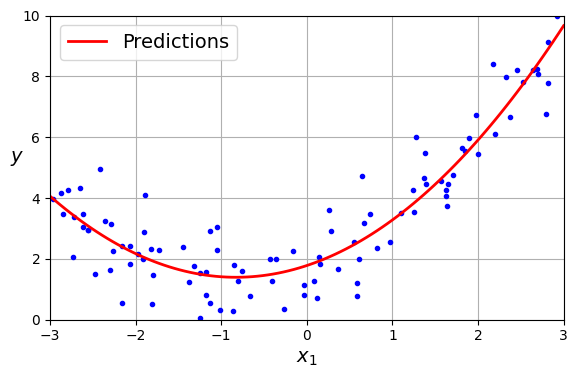

In [22]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_predictions_plot")
plt.show()

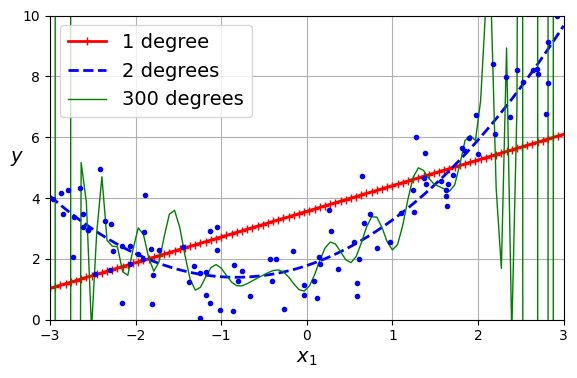

In [24]:
# 아래의 코드는 차수에 따른 고차 다항 회귀 모델의 예측을 나타낸다.
# degree=300에서, x, x^2, x^3, ... x^300을 생성하고, 그에 대한 가중치를 300개를 곱하여 더한 선형 결합의 모델을 계산한다.
# 시각화 그래프에서 볼 수 있듯이, 모델은 심각하게 과대적합되어 있음을 알 수 있다.

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(6, 4))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("high_degree_polynomials_plot")
plt.show()

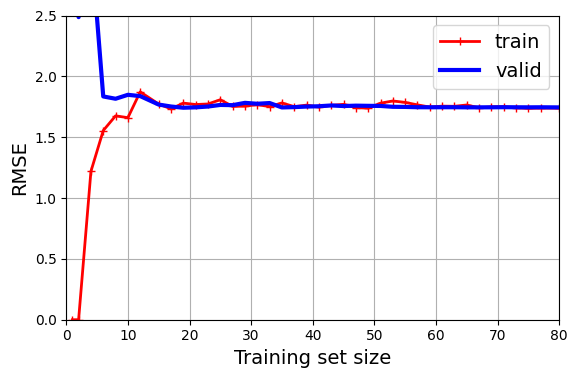

In [26]:
# 그렇다면, 위의 2차 방정식으로 직접 나타낸 예시와 달리, 일반적인 데이터에 대해
# 모델의 과대적합 또는 과소적합 여부를 어떻게 판단할 수 있을까?

# 이전의 k-폴드 교차 검증을 이용하거나, 학습 곡선을 확인해 볼 수 있다.
# 학습 곡선은 모델의 훈련 오차와 검증 오차를 나타내는데, 훈련 세트 크기를 점차 늘려나가며 매번 새로 fit()하여 모델을 평가,
# 각 훈련 세트 크기 별 훈련 점수와 검증 점수를 그래프에 나타낸 것이다.
# 즉, 예시로 처음에는 1개 샘플의 훈련 세트로 학습을 진행할 때, 당연히 하나의 샘플이므로 훈련 모델은 그대로 정답을 외워 0의 오차를 보이지만
# 그 모델로는 당연히 검증 세트에 대해 전혀 맞출 수 없으니 오차는 매우 클 것이다.
# 이후 점진적으로 훈련 세트 크기를 늘려나간다면, 모델 훈련 시 오차는 일정 존재하나 검증 세트에서도 어느 정도 오차를 줄인 모습을 보일 것이다.

# 그렇다면 아래의 학습 곡선을 보고 어떻게 판단할 수 있을까?
# 모델의 점수가 될 수 있는 RMSE에 대해 훈련 세트 크기를 계속해서 늘려도 훈련 및 검증 세트에서 수평적인 오차를 그리며
# 높은 오차에서 근접해 있으므로 모델이 과소적합, 훈련 샘플을 대변할 수 없는 모델임을 나타낸다. 그래프에서 볼 수 있듯이 훈련 샘플을 추가하는 것은 의미가 없다.

from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
save_fig("underfitting_learning_curves_plot")

plt.show()

In [27]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

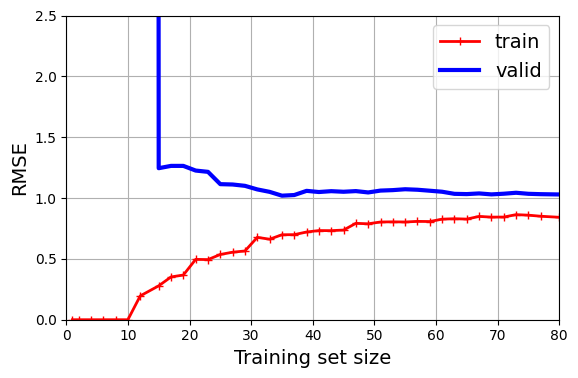

In [28]:
# 아래는 10차 다항 회귀 모델의 학습 곡선이다. 이전의 과소적합 모델과 달리 훈련 데이터의 오차가 훨씬 낮으나
# 훈련 오차와 검증 오차 간의 차이가 있는데, 이는 훈련 세트에 대한 오차는 적으나 검증 세트에서의 오차는 크므로
# 과대적합일 수 있음을 나타낸다. 이 때 과대적합 모델을 개선하기 위해서 더 많은 훈련 데이터를 추가하여
# 검증 오차가 훈련 오차에 근접하게 모델을 학습시켜 볼 수 있다.

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
save_fig("learning_curves_plot")
plt.show()